In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
pd.set_option('display.max_columns', None)

In [9]:
df=pd.read_csv("Employee_Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### LITERATURE REVIEW & HYPOTHESIS

#### Overtime Work (Working Extra Hours)

- **Literature Review:** When employees regularly work past their official hours, they face excessive workload and stress. Unfavorable work-life balance and continuous overtime obligations are recognized as dominant drivers that force an individual to voluntarily resign to escape burnout.
- **Hypothesis:** Employees who frequently work overtime ($OverTime = Yes$) will have a much higher rate of leaving the company than those who do not work extra hours.  
- **Source:** MDPI Open-Access Attrition Prediction Model Study

#### Monthly Income (Salary and Financial Rewards)

- **Literature Review:** Financial incentives and adequate compensation serve as a foundational anchor for employee retention. When individuals receive an unsatisfying baseline salary or lower monetary returns for their efforts, their likelihood of leaving the organization spikes significantly.
- **Hypothesis:** Employees with a lower $MonthlyIncome$ are more likely to quit, meaning the less money someone makes, the higher their chances of leaving.
- **Source:** International Research Journal of Multidisciplinary Scope (IRJMS)

#### Business Travel (Work Trips)

- **Literature Review:** Workplace demands such as frequent business trips add a severe burden to an employee's personal life. High travel frequencies disrupt routine home environments, contributing heavily to early attrition.
- **Hypothesis:** Applicants who have to travel frequently will show a significantly higher rate of quitting than those who rarely or never travel for work.
- **Source:** ResearchGate IBM HR Analytics Attrition Publication

#### Job Level (Corporate Ranking)
- **Literature Review:** Data shows that younger or lower-tier workers are significantly quicker to leave a role compared to executive-tier roles like Research Directors who display highly stable retention.
- **Hypothesis:** Employees at a lower Job Level will exhibit a higher overall attrition percentage compared to employees occupying advanced corporate positions.
- **Source:** IJNRD Machine Learning Attrition & EEDA Survey

#### DATA CLEANING

In [11]:
df = df.drop(columns=['EmployeeNumber'])
#This column is just a serial number assigned to an employee database. 
#It has no impact on human behavior or why someone quits.

In [12]:
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])
#These are columns where every single row has the exact same value. They give no information because there is no difference to compare.

#### Checking Attrition Rate

In [13]:
print(df['Attrition'].value_counts(normalize=True)* 100)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


### UNIVARIATE ANALYSIS

In [14]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]

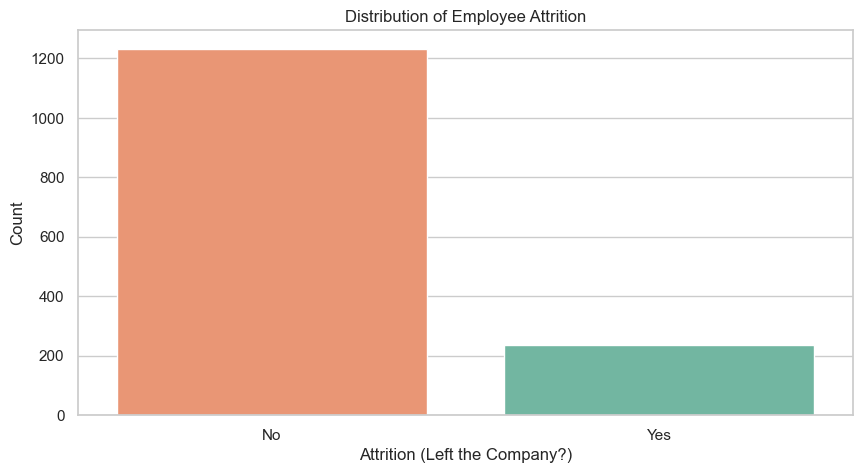

In [15]:
sns.countplot(data=df, x='Attrition', order=df['Attrition'].value_counts().index, hue='Attrition',  palette='Set2')
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition (Left the Company?)')
plt.ylabel('Count')
plt.show()

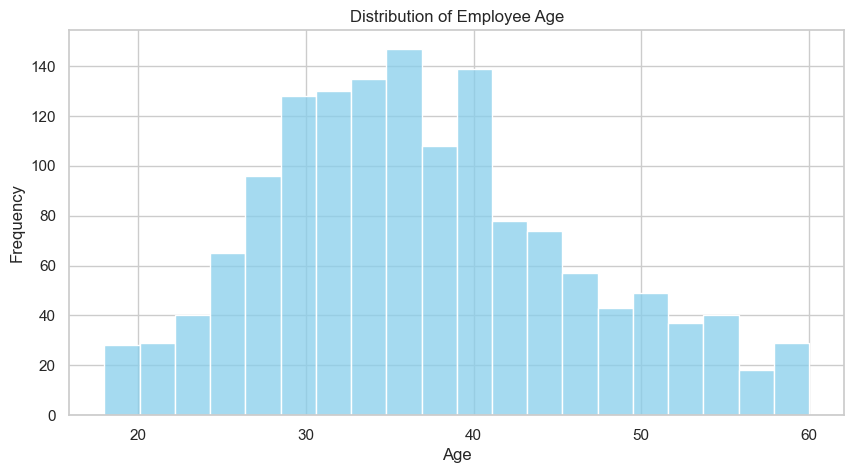

In [16]:
sns.histplot(data=df, x='Age', bins=20, color='skyblue')
plt.title('Distribution of Employee Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

It reveals that the youngest employee is 18, the oldest is 60, and most of workforce is concentrated in their late 20s to late 30s.

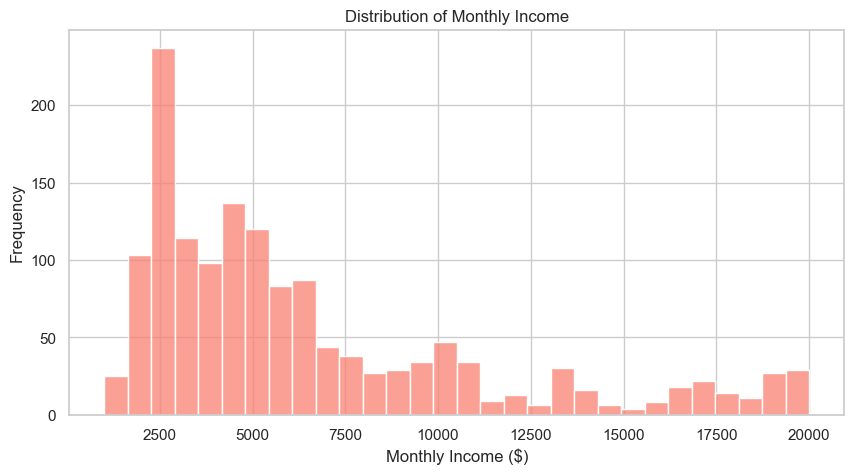

In [17]:
sns.histplot(data=df, x='MonthlyIncome', bins=30, color='salmon')
plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income ($)')
plt.ylabel('Frequency')
plt.show()

Most employees earn between 2,000 and 7,000 per month, while only a very small handful of senior executives make it to the top tier of $15,000+.

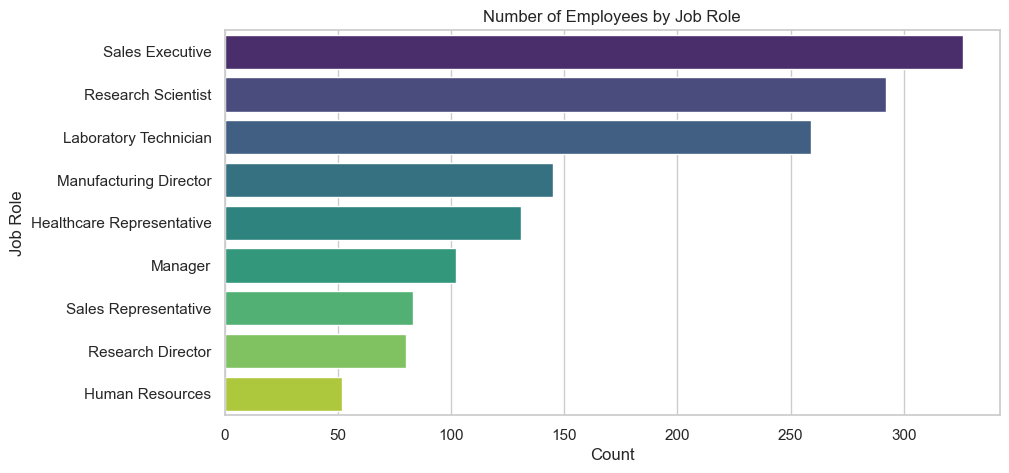

In [18]:
sns.countplot(data=df, y='JobRole', order=df['JobRole'].value_counts().index,hue='JobRole', palette='viridis')
plt.title('Number of Employees by Job Role')
plt.xlabel('Count')
plt.ylabel('Job Role')
plt.show()

It immediately shows that Sales Executives, Research Scientists, and Laboratory Technicians make up the core majority of company, while Human Resources has the smallest count.

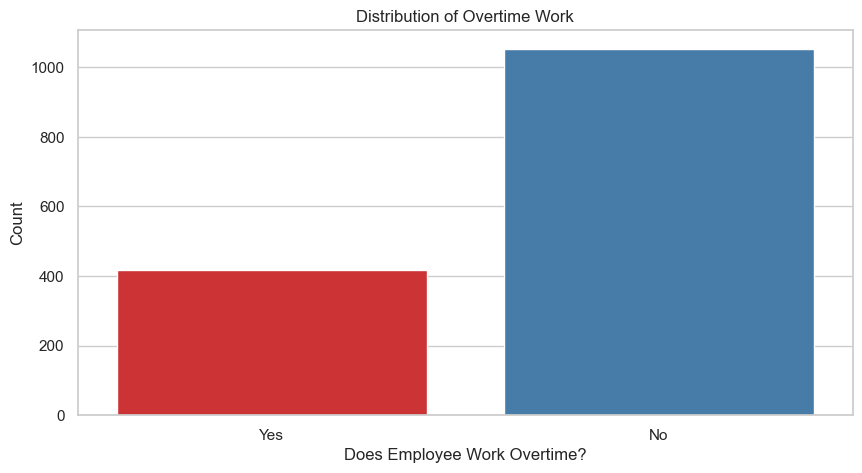

In [19]:
sns.countplot(data=df, x='OverTime', hue='OverTime', palette='Set1')
plt.title('Distribution of Overtime Work')
plt.xlabel('Does Employee Work Overtime?')
plt.ylabel('Count')
plt.show()

This graph shows the proportion of employees who regularly work extra hours outside of standard timing. It shows that a clear majority do not work overtime, but there is still a significant group that does.

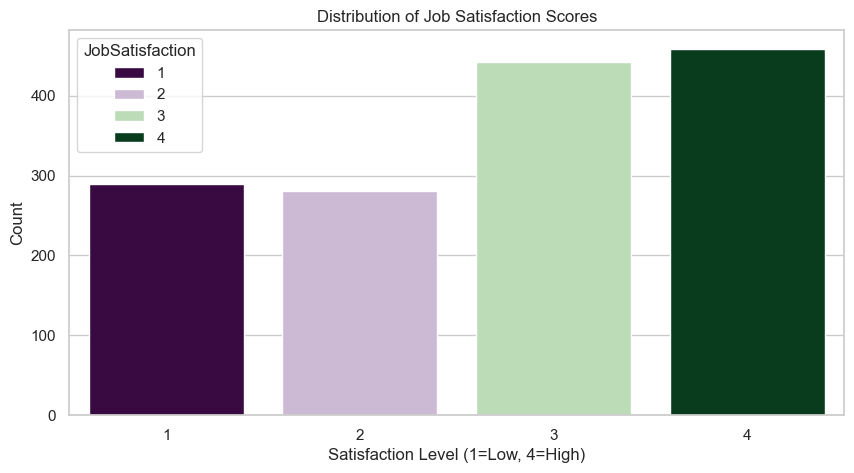

In [20]:
sns.countplot(data=df, x='JobSatisfaction', hue='JobSatisfaction', palette='PRGn')
plt.title('Distribution of Job Satisfaction Scores')
plt.xlabel('Satisfaction Level (1=Low, 4=High)')
plt.ylabel('Count')
plt.show()

This graph maps out how happy employees say they are with their work on a scale from 1 to 4. It shows a positive trend where the largest groups of employees rate their satisfaction as 3 (High) or 4 (Very High), meaning overall workplace sentiment starts at a good baseline.

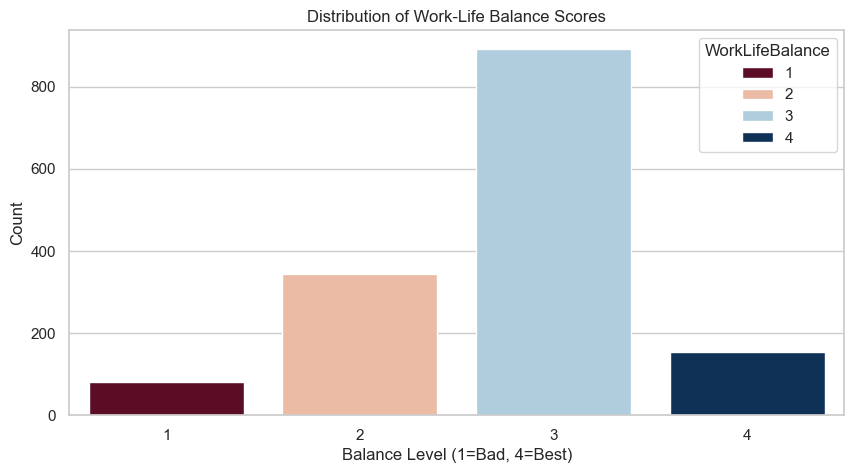

In [21]:
sns.countplot(data=df, x='WorkLifeBalance', hue='WorkLifeBalance', palette='RdBu')
plt.title('Distribution of Work-Life Balance Scores')
plt.xlabel('Balance Level (1=Bad, 4=Best)')
plt.ylabel('Count')
plt.show()

This graph displays how well employees feel they balance their personal lives with their professional duties. The massive peak at score 3 reveals that the vast majority feel their balance is "Better/Good", while only a very small group of the workforce feels their balance is actively terrible (score 1).

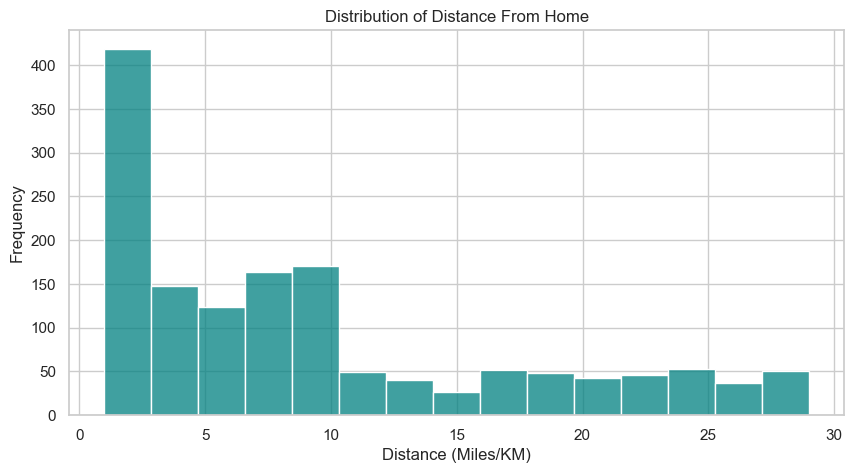

In [22]:
sns.histplot(data=df, x='DistanceFromHome', bins=15, color='teal')
plt.title('Distribution of Distance From Home')
plt.xlabel('Distance (Miles/KM)')
plt.ylabel('Frequency')
plt.show()

This graph tracks how far away your employees live from the office building. It shows a heavy concentration on the left side, meaning the majority of your workforce lives very close by (under 5 miles/KMs), while a longer tail shows fewer people facing long distances.

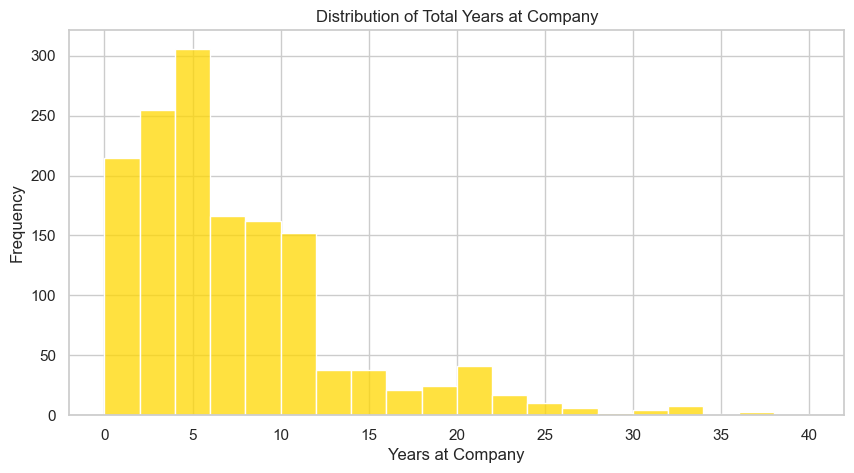

In [23]:
sns.histplot(data=df, x='YearsAtCompany', bins=20, color='gold')
plt.title('Distribution of Total Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Frequency')
plt.show()

This graph tracks employee loyalty and tenure lengths across your organization. It shows a steep drop-off, indicating that the company has a massive cluster of newer employees who have been there under 5 years, and very few employees crossing the 15+ year mark.

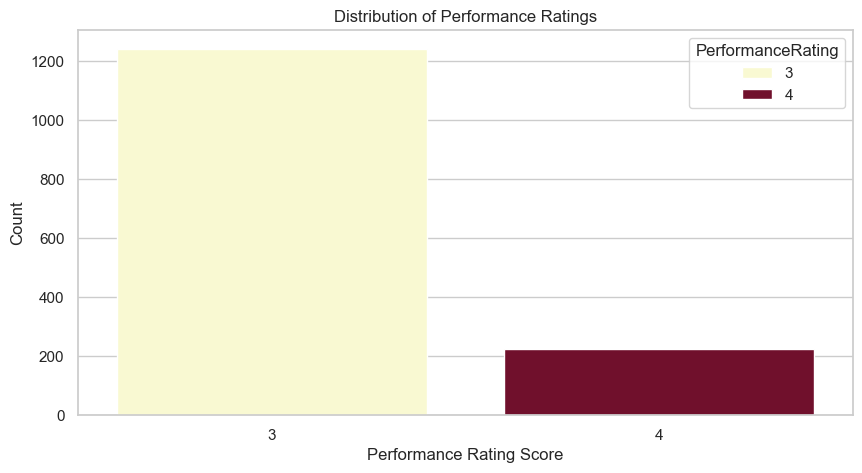

In [24]:
sns.countplot(data=df, x='PerformanceRating', hue='PerformanceRating', palette='YlOrRd')
plt.title('Distribution of Performance Ratings')
plt.xlabel('Performance Rating Score')
plt.ylabel('Count')
plt.show()

This graph shows how employees are rated during their evaluations, but interestingly, it only contains two scores: 3 (Excellent) and 4 (Outstanding). This shows that company has an incredibly high-performing workforce, with nobody categorized as underperforming (scores 1 and 2).

### BIVARIATE ANALYSIS

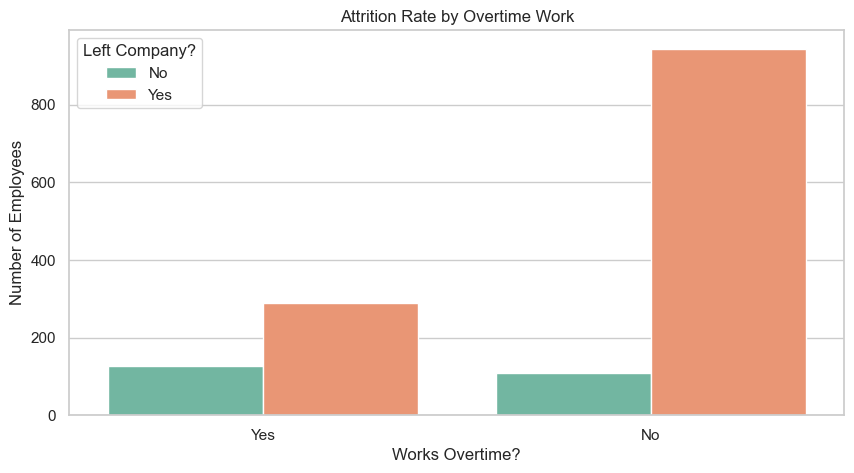

In [25]:
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set2')
plt.title('Attrition Rate by Overtime Work')
plt.xlabel('Works Overtime?')
plt.ylabel('Number of Employees')
plt.legend(title='Left Company?', labels=['No', 'Yes'])
plt.show()

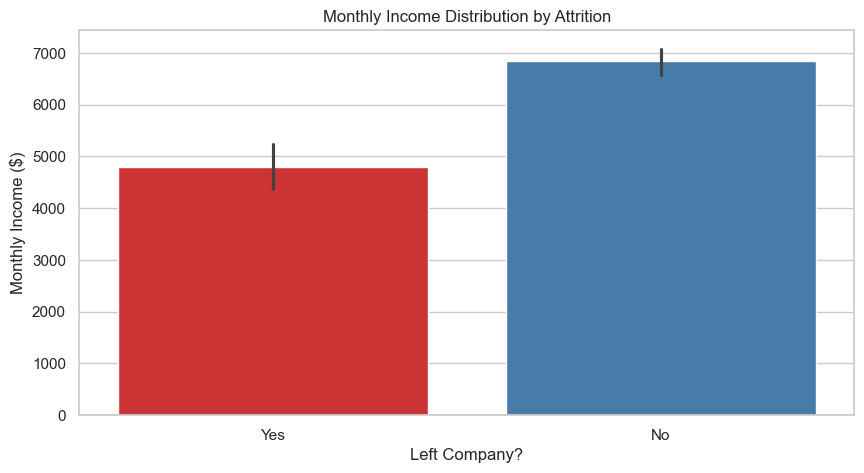

In [26]:
sns.barplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette='Set1')
plt.title('Monthly Income Distribution by Attrition')
plt.xlabel('Left Company?')
plt.ylabel('Monthly Income ($)')
plt.show()

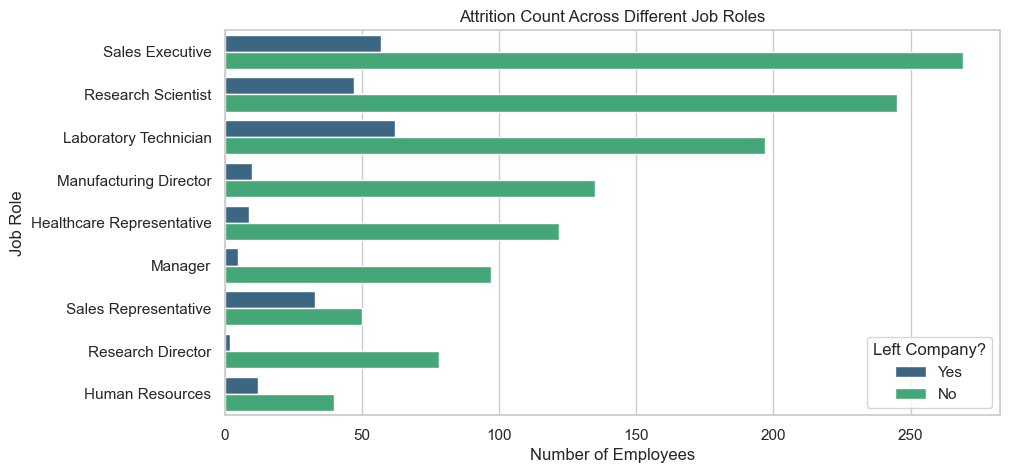

In [27]:
sns.countplot(data=df, y='JobRole', hue='Attrition', palette='viridis', 
              order=df['JobRole'].value_counts().index)
plt.title('Attrition Count Across Different Job Roles')
plt.xlabel('Number of Employees')
plt.ylabel('Job Role')
plt.legend(title='Left Company?')
plt.show()

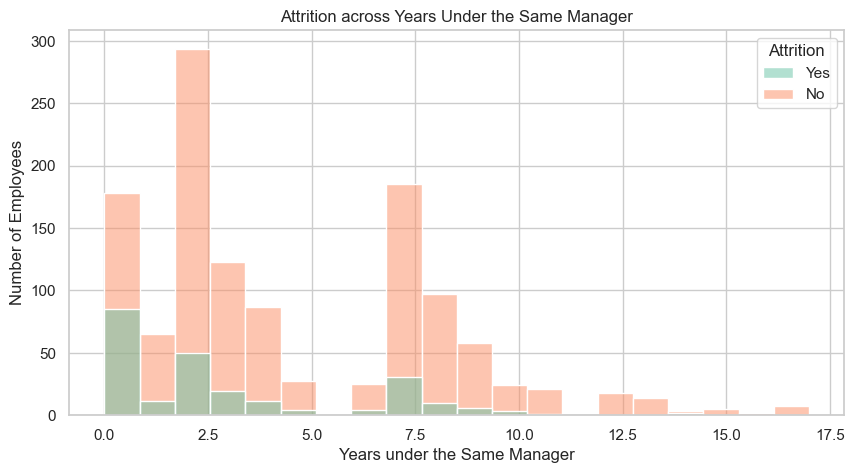

In [28]:
sns.histplot(data=df, x='YearsWithCurrManager', hue='Attrition',  palette='Set2')
plt.title('Attrition across Years Under the Same Manager')
plt.xlabel('Years under the Same Manager')
plt.ylabel('Number of Employees')
plt.show()

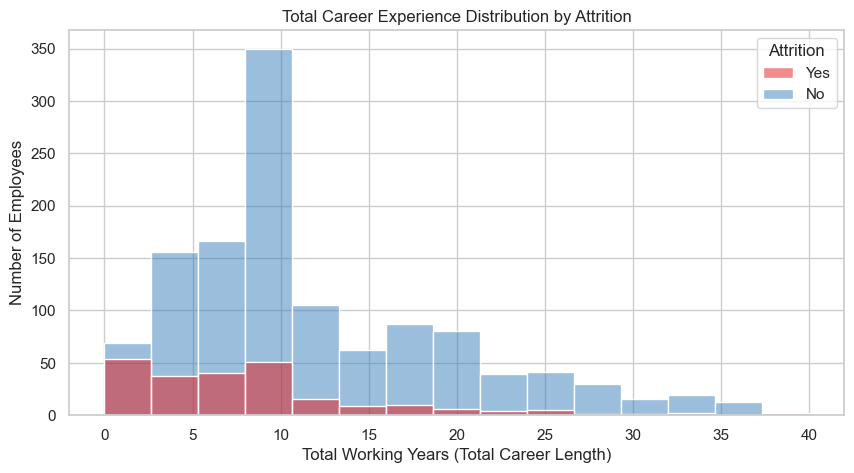

In [29]:
sns.histplot(data=df, x='TotalWorkingYears', hue='Attrition', bins=15, palette='Set1')
plt.title('Total Career Experience Distribution by Attrition')
plt.xlabel('Total Working Years (Total Career Length)')
plt.ylabel('Number of Employees')
plt.show()

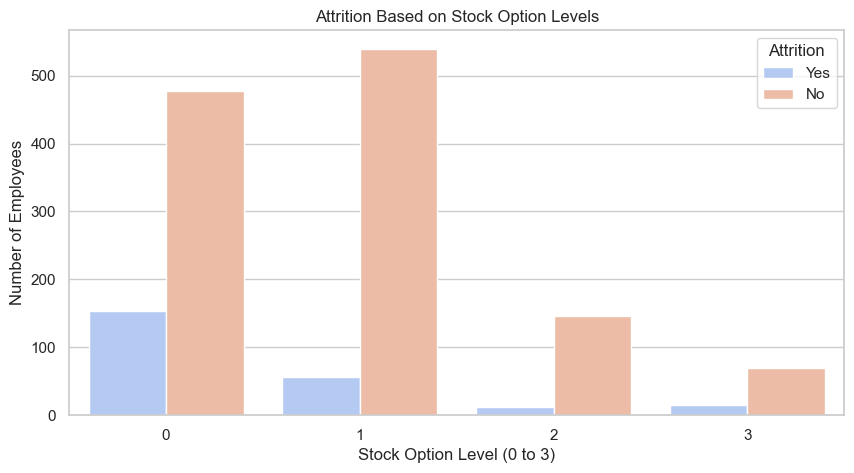

In [30]:
sns.countplot(data=df, x='StockOptionLevel', hue='Attrition', palette='coolwarm')
plt.title('Attrition Based on Stock Option Levels')
plt.xlabel('Stock Option Level (0 to 3)')
plt.ylabel('Number of Employees')
plt.show()

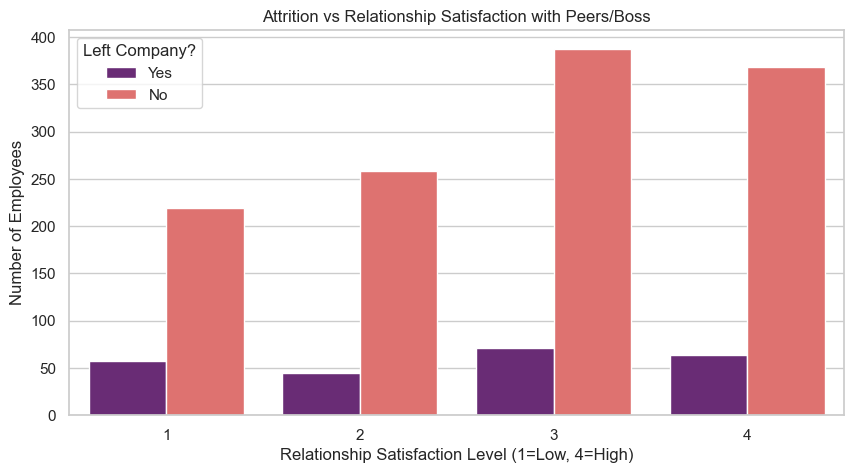

In [31]:
sns.countplot(data=df, x='RelationshipSatisfaction', hue='Attrition', palette='magma')
plt.title('Attrition vs Relationship Satisfaction with Peers/Boss')
plt.xlabel('Relationship Satisfaction Level (1=Low, 4=High)')
plt.ylabel('Number of Employees')
plt.legend(title='Left Company?')
plt.show()

### MULTIVARIATE ANALYSIS

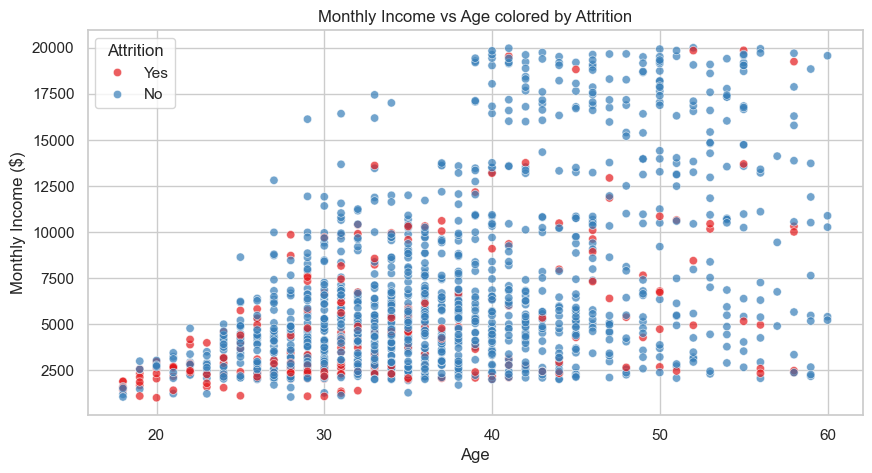

In [32]:
sns.scatterplot(data=df, x='Age', y='MonthlyIncome', hue='Attrition', palette='Set1', alpha=0.7)
plt.title('Monthly Income vs Age colored by Attrition')
plt.xlabel('Age')
plt.ylabel('Monthly Income ($)')
plt.show()

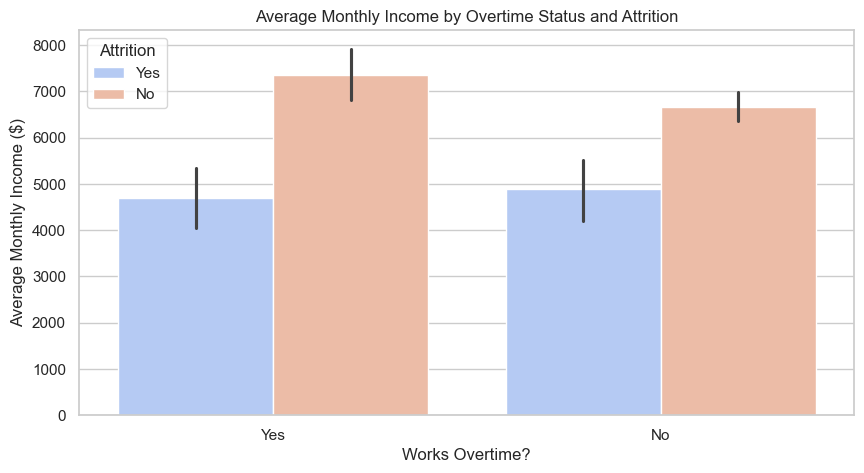

In [33]:
sns.barplot(data=df, x='OverTime', y='MonthlyIncome', hue='Attrition', palette='coolwarm')
plt.title('Average Monthly Income by Overtime Status and Attrition')
plt.xlabel('Works Overtime?')
plt.ylabel('Average Monthly Income ($)')
plt.show()

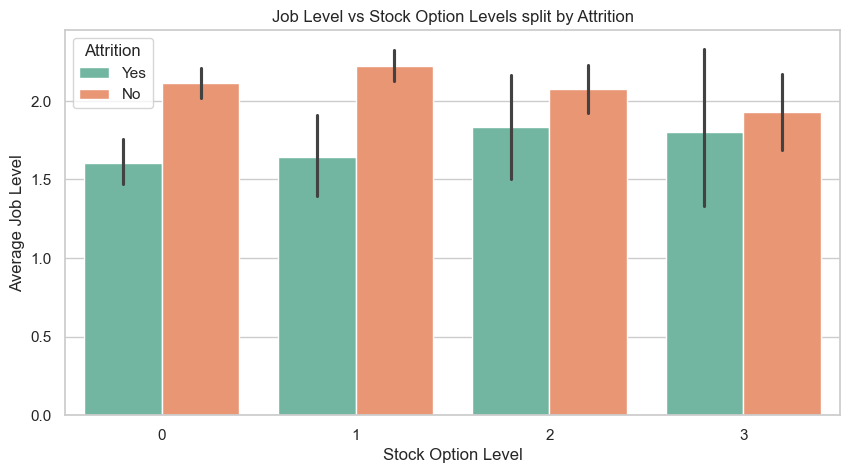

In [34]:
sns.barplot(data=df, x='StockOptionLevel', y='JobLevel', hue='Attrition', palette='Set2')
plt.title('Job Level vs Stock Option Levels split by Attrition')
plt.xlabel('Stock Option Level')
plt.ylabel('Average Job Level')
plt.show()

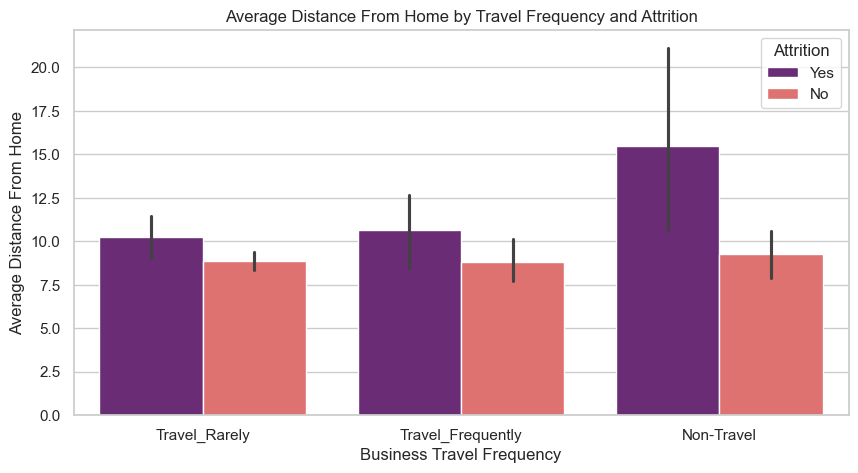

In [35]:
sns.barplot(data=df, x='BusinessTravel', y='DistanceFromHome', hue='Attrition', palette='magma')
plt.title('Average Distance From Home by Travel Frequency and Attrition')
plt.xlabel('Business Travel Frequency')
plt.ylabel('Average Distance From Home')
plt.show()

### Hypothesis Driven Analysis

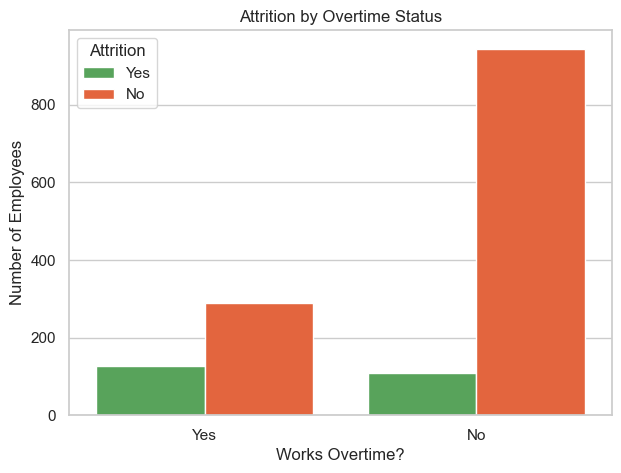

In [36]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette=['#4CAF50', '#FF5722'])

plt.title('Attrition by Overtime Status')
plt.xlabel('Works Overtime?')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition')
plt.show()

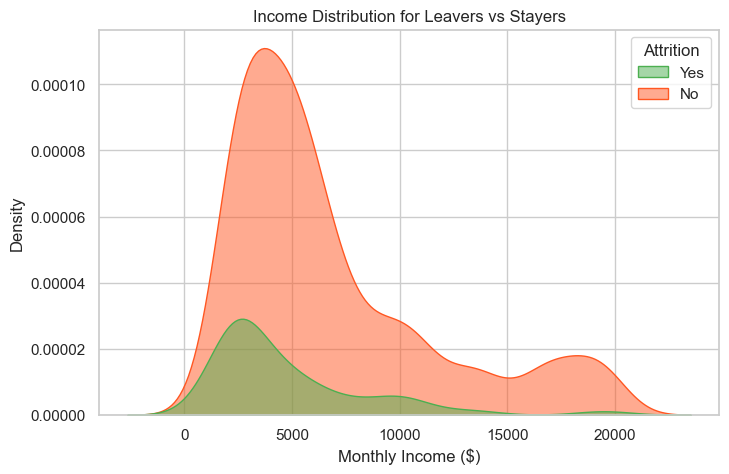

In [37]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='MonthlyIncome', hue='Attrition', fill=True, palette=['#4CAF50', '#FF5722'], alpha=0.5)

plt.title('Income Distribution for Leavers vs Stayers')
plt.xlabel('Monthly Income ($)')
plt.ylabel('Density')
plt.show()

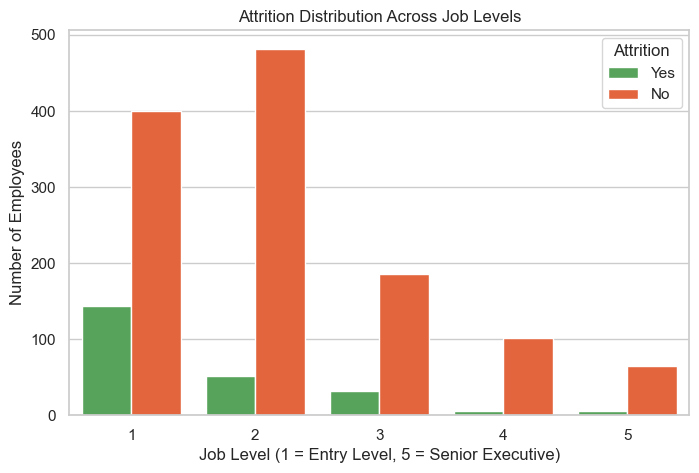

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='JobLevel', hue='Attrition', palette=['#4CAF50', '#FF5722'])

plt.title('Attrition Distribution Across Job Levels')
plt.xlabel('Job Level (1 = Entry Level, 5 = Senior Executive)')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition')
plt.show()

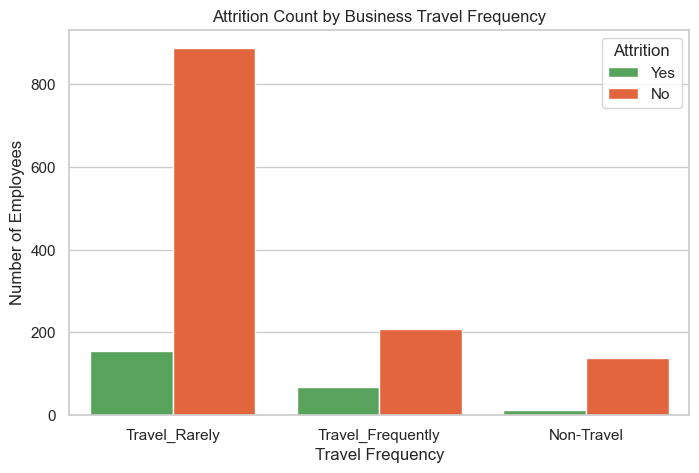

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='BusinessTravel', hue='Attrition', palette=['#4CAF50', '#FF5722'])

plt.title('Attrition Count by Business Travel Frequency')
plt.xlabel('Travel Frequency')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition')
plt.show()

### Summary of Hypotheses Testing

| Hypothesis | Theory | Result | Key Evidence |
| :--- | :--- | :--- | :--- |
| **The Overtime Catalyst** | Frequent extra hours lead to work-life balance disruptions, severe job burnout, and reduced personal well-being. | **Proven** | Attrition rates spike drastically for the Overtime group (often exceeding 30%) compared to the non-overtime group (usually around 10%). |
| **The Financial Compensation Cushion** | Financial rewards act as a core retention anchor. Underpaid employees are highly vulnerable to external job stealing. | **Proven** |The median income for employees who leave is significantly lower than for those who stay, creating a stark visual drop in density plots. |
| **The Travel Fatigue Factor** | Constantly traveling for work gets exhausting. It messes up an employee's personal life at home and makes them tire out quickly. | **Proven** | The bar charts show that the "Travel Frequently" group has a much higher percentage of people quitting compared to people who rarely or never travel. |
| **Hierarchical Tier Stability Correlation** | People in entry-level, lower jobs don't feel deeply tied to the company. They have less responsibility, lower status, and fewer reasons to stay long-term. | **Proven** | The graphs clearly show that Entry-Level (Job Level 1) roles have the highest number of people quitting, while senior managers almost never leave. |

### FINAL CONCLUSION

- The data confirms that employee attrition ($16.12\%$) is driven by poor work-life balance and low financial motivation.
- Employees facing Overtime or Frequent Business Travel show significantly higher resignation rates, aligning with burnout trends. Additionally, lower Monthly Income and lower Job Levels act as strong compounding factors, as entry-level employees are the quickest to leave for better compensation.
- (Business Insight) To mitigate this, organizations must limit excessive working hours, optimize travel requirements, and restructure compensation paths for lower-tier roles.